In [1]:
import xarray as xr
import numpy as np
from scipy.optimize import minimize
import warnings
import os

In [2]:
import dask.array as da
from dask.distributed import Client, LocalCluster
# Optional: Set up Dask for parallel processing
# Adjust memory/cores as needed for your system or cluster
try:
    cluster = LocalCluster(n_workers=10,threads_per_worker=1)
    client = Client(cluster)
    print("Dask client started:")
    print(client)
    print(f"Dask dashboard link: {client.dashboard_link}")
except Exception as e:
    print(f"Could not start Dask client: {e}. Running sequentially.")
    client = None


Dask client started:
<Client: 'tcp://127.0.0.1:36113' processes=5 threads=5, memory=503.64 GiB>
Dask dashboard link: http://127.0.0.1:8787/status


## Preprocessing steps

In [ ]:

# --- Configuration ---
# Define paths to your Zarr stores
# Replace with your actual paths
sif_zarr_path = "/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/SIF_TROPOMI_gridded_10km_filtered_europe_2018-05-04_2020-12-26.zarr/"
lst_zarr_path = "/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/LST_Sentinel3_gridded_1km_europe_2018-01-04_2020-12-29.zarr/"
modis_zarr_path = "/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/MC43A4_gridded_1km_europe_2018-05-01_2020-12-31_YAXA.zarr/"
sentinel3_zarr_path = "/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/OLCI_Sentinel3_gridded_1km_europe_2018-01-04_2020-12-29.zarr/"


In [4]:

# Output paths for intermediate and final data
# Replace with your desired output directory
output_dir = "/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/"
os.makedirs(output_dir, exist_ok=True) # Create output dir if it doesn't exist

sif_low_july_path = os.path.join(output_dir, "sif_cube_low_july.zarr")
lst_high_july_path = os.path.join(output_dir, "lst_cube_high_july.zarr")
ogvi_high_july_path = os.path.join(output_dir, "ogvi_cube_high_july.zarr")
ndwi_high_july_path = os.path.join(output_dir, "ndwi_cube_high_july.zarr")

lst_low_july_path = os.path.join(output_dir, "low_res", "lst_cube_low_july.zarr")
ndwi_low_july_path = os.path.join(output_dir, "low_res", "ndwi_cube_low_july.zarr")
ogvi_low_july_path = os.path.join(output_dir, "low_res", "ogvi_cube_low_july.zarr")

params_low_path = os.path.join(output_dir, "parameters_cube_low_OGVI.zarr")
params_high_path = os.path.join(output_dir, "parameters_cube_high_OGVI.zarr")
sif_high_path = os.path.join(output_dir, "sif_downscaled_high_OGVI.zarr")


In [5]:
# --- Data Loading and Preprocessing ---
print("Loading and preprocessing data...")

Loading and preprocessing data...


In [6]:
# --- SIF Low Resolution ---
print("  Loading SIF...")
sif_cube = xr.open_zarr(sif_zarr_path, chunks={})
sif_cube

  Loading SIF...


<xarray.Dataset> Size: 3GB
Dimensions:        (time: 952, lat: 480, lon: 480)
Coordinates:
  * time           (time) datetime64[ns] 8kB 2018-05-04 ... 2020-12-26
  * lon            (lon) int64 4kB 0 1 2 3 4 5 6 ... 473 474 475 476 477 478 479
  * lat            (lat) int64 4kB 479 478 477 476 475 474 473 ... 6 5 4 3 2 1 0
Data variables:
    SIF_Corr_743   (time, lat, lon) float32 877MB dask.array<chunksize=(1, 480, 480), meta=np.ndarray>
    SIF_ERROR_743  (time, lat, lon) float32 877MB dask.array<chunksize=(1, 480, 480), meta=np.ndarray>
    lat_grid       (lat, lon) float32 922kB dask.array<chunksize=(240, 240), meta=np.ndarray>
    lon_grid       (lat, lon) float32 922kB dask.array<chunksize=(240, 240), meta=np.ndarray>
    SIF_743        (time, lat, lon) float32 877MB dask.array<chunksize=(1, 480, 480), meta=np.ndarray>

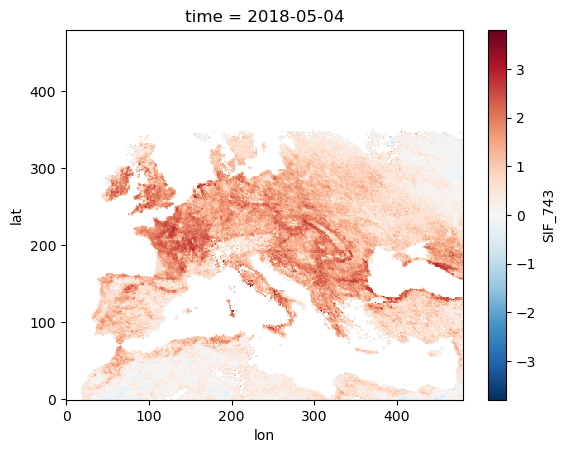

In [7]:
sif_cube['SIF_743'].isel(time = 0).plot()

In [8]:
# Select July 2018 and SIF_743 variable

sif_cube_low = sif_cube['SIF_743'].sel(time=slice('2018-07-01', '2018-07-31'))
# Calculate temporal mean for July
print("  Calculating SIF temporal mean...")
sif_cube_low_july = sif_cube_low.mean(dim='time', skipna=True, keep_attrs=False)


  Calculating SIF temporal mean...


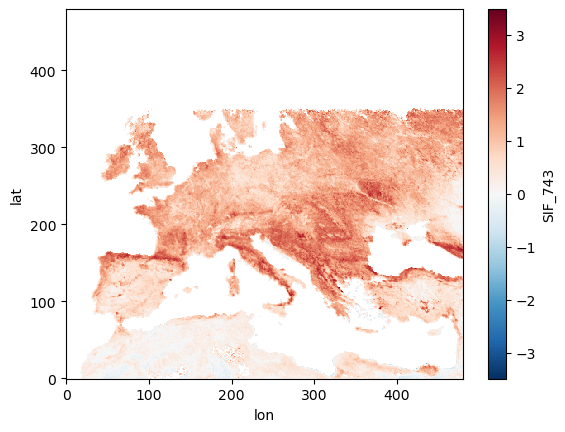

In [9]:
sif_cube_low_july.plot()

In [10]:
sif_cube_low_july

<xarray.DataArray 'SIF_743' (lat: 480, lon: 480)> Size: 922kB
dask.array<mean_agg-aggregate, shape=(480, 480), dtype=float32, chunksize=(480, 480), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) int64 4kB 0 1 2 3 4 5 6 7 ... 472 473 474 475 476 477 478 479
  * lat      (lat) int64 4kB 479 478 477 476 475 474 473 472 ... 7 6 5 4 3 2 1 0

In [11]:
sif_cube_low_july = sif_cube_low_july.chunk({'lat':80, 'lon': 80})

In [12]:
# --- LST High Resolution ---
print("  Loading LST...")
lst_cube = xr.open_zarr(lst_zarr_path, chunks={})
lst_cube

  Loading LST...


<xarray.Dataset> Size: 25GB
Dimensions:    (lat: 4800, lon: 4800, time: 136)
Coordinates:
  * lat        (lat) int64 38kB 4799 4798 4797 4796 4795 4794 ... 5 4 3 2 1 0
  * time       (time) datetime64[ns] 1kB 2018-01-04 2018-01-12 ... 2020-12-29
  * lon        (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799
Data variables:
    lon_grid   (lat, lon) float32 92MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    LST_sigma  (time, lat, lon) float32 13GB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    lat_grid   (lat, lon) float32 92MB dask.array<chunksize=(400, 400), meta=np.ndarray>
    LST        (time, lat, lon) float32 13GB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>

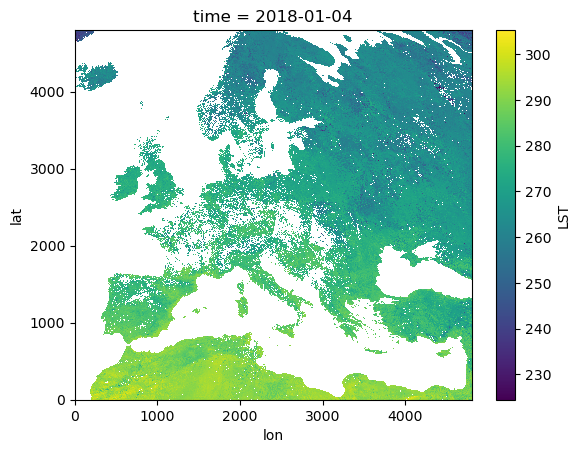

In [13]:
lst_cube['LST'].isel(time = 0).plot()

In [14]:
lst_cube_high = lst_cube['LST'].sel(time=slice('2018-07-01', '2018-07-31'))
print("  Calculating LST temporal mean...")
lst_cube_high_july = lst_cube_high.mean(dim='time', skipna=True, keep_attrs=True)

  Calculating LST temporal mean...


In [15]:
lst_cube_high_july = lst_cube_high_july.chunk({'lat':400, 'lon': 400})

In [16]:
# Ensure spatial dimensions match expected names (e.g., 'X', 'Y') - Adjust if necessary
# lst_cube_high_july = lst_cube_high_july.rename({'latitude': 'Y', 'longitude': 'X'})
lst_cube_high_july.to_zarr(lst_high_july_path, mode='w')
print(f"  Saved LST high res July to {lst_high_july_path}")
del lst_cube, lst_cube_high

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Saved LST high res July to /Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/lst_cube_high_july.zarr


In [17]:
sif_cube_low_july.to_zarr(sif_low_july_path, mode='w')
print(f"  Saved SIF low res July to {sif_low_july_path}")
del sif_cube, sif_cube_low # Free up memory

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Saved SIF low res July to /Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/sif_cube_low_july.zarr


In [18]:
# --- MODIS High Resolution (for NDWI) ---
print("  Loading MODIS...")
modis_cube = xr.open_zarr(modis_zarr_path, chunks='auto')
modis_cube_high = modis_cube.sel(time=slice('2018-07-01', '2018-07-31'))
modis_cube_high = modis_cube_high

  Loading MODIS...


In [19]:
# Calculate NDWI: (NIR - SWIR) / (NIR + SWIR)
print("  Calculating NDWI...")
b4 = modis_cube_high['B4']
b2 = modis_cube_high['B2']
ndwi_cube_high = (b2 - b4 ) / (b2 + b4)
ndwi_cube_high = ndwi_cube_high.rename('NDWI') # Rename the DataArray
ndwi_cube_high.attrs['long_name'] = 'Normalized Difference Water Index (Band4-Band2)/(Band4+Band2)'
ndwi_cube_high

  Calculating NDWI...


<xarray.DataArray 'NDWI' (time: 31, lat: 4800, lon: 4800)> Size: 3GB
dask.array<truediv, shape=(31, 4800, 4800), dtype=float32, chunksize=(1, 4800, 4800), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) int64 38kB 4799 4798 4797 4796 4795 4794 4793 ... 5 4 3 2 1 0
  * time     (time) datetime64[ns] 248B 2018-07-01 2018-07-02 ... 2018-07-31
  * lon      (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799
Attributes:
    long_name:  Normalized Difference Water Index (Band4-Band2)/(Band4+Band2)

In [20]:
print("  Calculating NDWI temporal mean...")
ndwi_cube_high_july = ndwi_cube_high.mean(dim='time', skipna=True, keep_attrs=True)

  Calculating NDWI temporal mean...


In [21]:
ndwi_cube_high_july = ndwi_cube_high_july.chunk({'lat':400, 'lon': 400})

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:758: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Net/Groups/BGI/scratch/dpabon

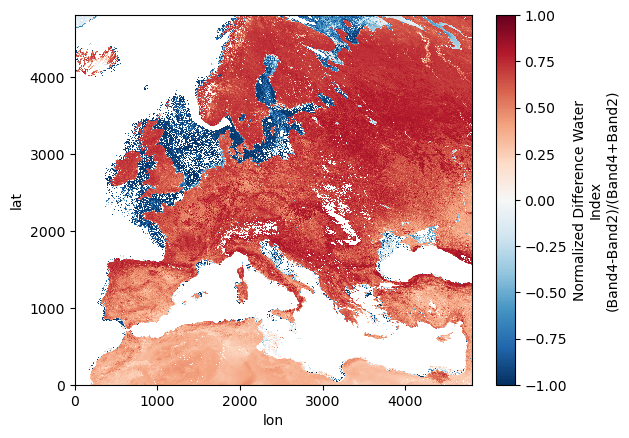

In [22]:
ndwi_cube_high_july.plot()

In [23]:
ndwi_cube_high_july.to_zarr(ndwi_high_july_path, mode='w')

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [24]:
# --- Sentinel-3 High Resolution (OGVI) ---
print("  Loading Sentinel-3 OGVI...")
sentinel_3_cube = xr.open_zarr(sentinel3_zarr_path, chunks={})
ogvi_cube_high = sentinel_3_cube['OGVI'].sel(time=slice('2018-07-01', '2018-07-31'))

  Loading Sentinel-3 OGVI...


In [25]:
ogvi_cube_high

<xarray.DataArray 'OGVI' (time: 4, lat: 4800, lon: 4800)> Size: 369MB
dask.array<getitem, shape=(4, 4800, 4800), dtype=float32, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) int64 38kB 4799 4798 4797 4796 4795 4794 4793 ... 5 4 3 2 1 0
  * time     (time) datetime64[ns] 32B 2018-07-06 2018-07-14 ... 2018-07-30
  * lon      (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799

In [26]:
print("  Calculating OGVI temporal mean...")
ogvi_cube_high_july = ogvi_cube_high.mean(dim='time', skipna=True, keep_attrs=True)
print(f"OGVI high res July shape: {ogvi_cube_high_july.shape}")

  Calculating OGVI temporal mean...
OGVI high res July shape: (4800, 4800)


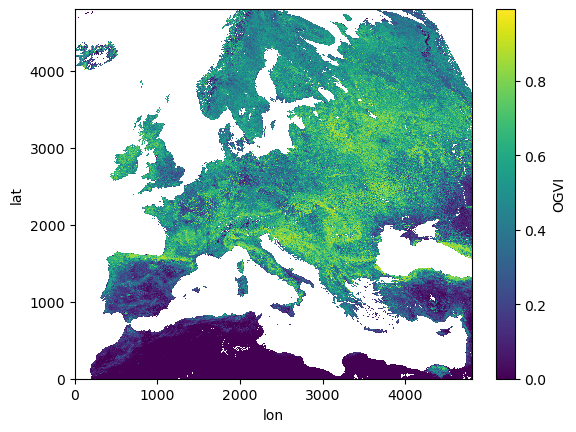

In [27]:
ogvi_cube_high_july.plot()

In [28]:
ogvi_cube_high_july = ogvi_cube_high_july.chunk({'lat':400, 'lon': 400})

In [29]:
ogvi_cube_high_july.to_zarr(ogvi_high_july_path, mode='w')
print(f"  Saved OGVI high res July to {ogvi_high_july_path}")


print("Finished loading and initial preprocessing.")

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Saved OGVI high res July to /Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/ogvi_cube_high_july.zarr
Finished loading and initial preprocessing.


## Aggregating data to match SIF 10 km original resolution

In [30]:

# --- Reload temporally averaged data ---
print("Reloading temporally averaged data...")
sif_cube_low_july = xr.open_zarr(sif_low_july_path)
lst_cube_high_july = xr.open_zarr(lst_high_july_path)
ogvi_cube_high_july = xr.open_zarr(ogvi_high_july_path)
ndwi_cube_high_july = xr.open_zarr(ndwi_high_july_path)


Reloading temporally averaged data...


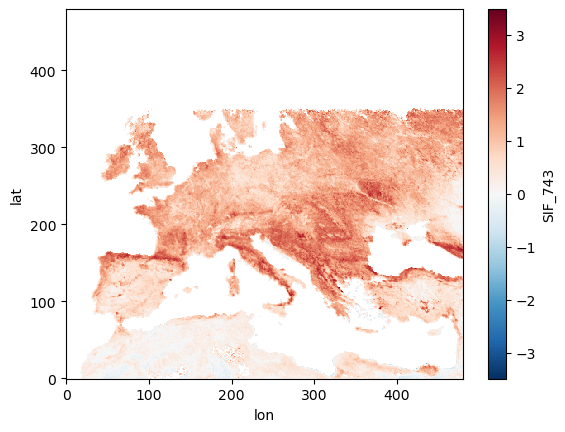

In [31]:
sif_cube_low_july['SIF_743'].plot()

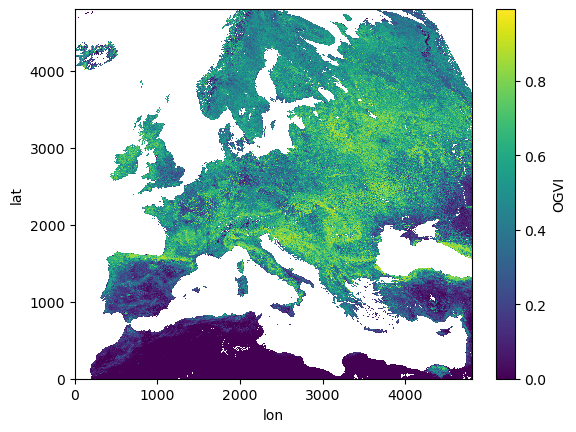

In [32]:
ogvi_cube_high_july['OGVI'].plot()

In [33]:
# --- Spatial Aggregation ---
# !!! This step needs to be improved check: https://xesmf.readthedocs.io/en/stable/notebooks/Dataset.html

# Aggregate high-res data (1km) to low-res SIF grid (10km)
print("Aggregating high-resolution data to low resolution...")
scale_factor = 10 # Assuming 10km / 1km = 10
# Check dimension names - replace 'X', 'Y' if needed


Aggregating high-resolution data to low resolution...


/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:757: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:757: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:757: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:757: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/dask/_task_spec.py:757: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Net/Groups/BGI/scratch/dpabon

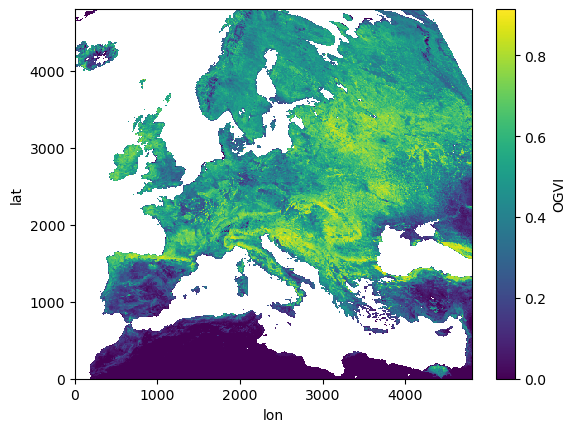

In [34]:
ogvi_cube_high_july['OGVI'].coarsen(lat = scale_factor, lon = scale_factor).reduce('median').plot()

In [35]:
# Aggregate each variable
lst_cube_low = lst_cube_high_july.coarsen(lat = scale_factor, lon = scale_factor).reduce('median')
ndwi_cube_low = ndwi_cube_high_july.coarsen(lat = scale_factor, lon = scale_factor).reduce('median')
ogvi_cube_low = ogvi_cube_high_july.coarsen(lat = scale_factor, lon = scale_factor).reduce('median')

In [36]:
sif_cube_low_july

<xarray.Dataset> Size: 929kB
Dimensions:  (lon: 480, lat: 480)
Coordinates:
  * lon      (lon) int64 4kB 0 1 2 3 4 5 6 7 ... 472 473 474 475 476 477 478 479
  * lat      (lat) int64 4kB 479 478 477 476 475 474 473 472 ... 7 6 5 4 3 2 1 0
Data variables:
    SIF_743  (lat, lon) float32 922kB dask.array<chunksize=(80, 80), meta=np.ndarray>

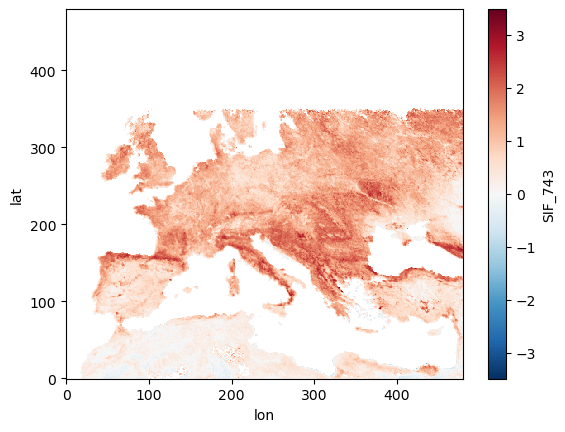

In [37]:
sif_cube_low_july['SIF_743'].plot()

In [41]:
# --- Align Grids (Crucial Step) ---
# Ensure all low-resolution datasets have the exact same coordinates and dimensions
# Use the SIF grid as the target grid
print("Aligning low-resolution grids...")
sif_cube_low_july = sif_cube_low_july.assign_coords({'lat': lst_cube_low.lat.values, 'lon': lst_cube_low.lon.values})
#lst_cube_low = lst_cube_low.assign_coords({'lat': sif_cube_low_july.lat.values, 'lon': sif_cube_low_july.lon.values}) 
ogvi_cube_low = ogvi_cube_low.assign_coords({'lat': lst_cube_low.lat.values, 'lon': lst_cube_low.lon.values}) 
ndwi_cube_low = ndwi_cube_low.assign_coords({'lat': lst_cube_low.lat.values, 'lon': lst_cube_low.lon.values}) 

Aligning low-resolution grids...


In [42]:
sif_cube_low_july['SIF_743']

<xarray.DataArray 'SIF_743' (lat: 480, lon: 480)> Size: 922kB
dask.array<open_dataset-SIF_743, shape=(480, 480), dtype=float32, chunksize=(80, 80), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 4.794e+03 4.784e+03 4.774e+03 ... 24.5 14.5 4.5
  * lon      (lon) float64 4kB 4.5 14.5 24.5 ... 4.774e+03 4.784e+03 4.794e+03

In [44]:
lst_cube_low['LST']

<xarray.DataArray 'LST' (lat: 480, lon: 480)> Size: 922kB
dask.array<nanmedian, shape=(480, 480), dtype=float32, chunksize=(8, 8), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 4kB 4.5 14.5 24.5 ... 4.774e+03 4.784e+03 4.794e+03
  * lat      (lat) float64 4kB 4.794e+03 4.784e+03 4.774e+03 ... 24.5 14.5 4.5

In [45]:
sif_cube_low_july['SIF_743'].encoding

{'chunks': (80, 80),
 'preferred_chunks': {'lat': 80, 'lon': 80},
 'compressors': (ZstdCodec(level=0, checksum=False),),
 'filters': (),
 'shards': None,
 'serializer': BytesCodec(endian=<Endian.little: 'little'>),
 '_FillValue': nan,
 'dtype': dtype('float32')}

In [46]:
sif_cube_low_july['SIF_743'].encoding

{'chunks': (80, 80),
 'preferred_chunks': {'lat': 80, 'lon': 80},
 'compressors': (ZstdCodec(level=0, checksum=False),),
 'filters': (),
 'shards': None,
 'serializer': BytesCodec(endian=<Endian.little: 'little'>),
 '_FillValue': nan,
 'dtype': dtype('float32')}

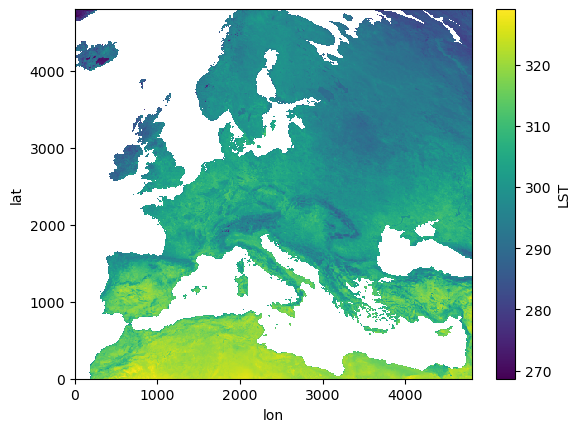

In [47]:
lst_cube_low['LST'].plot()

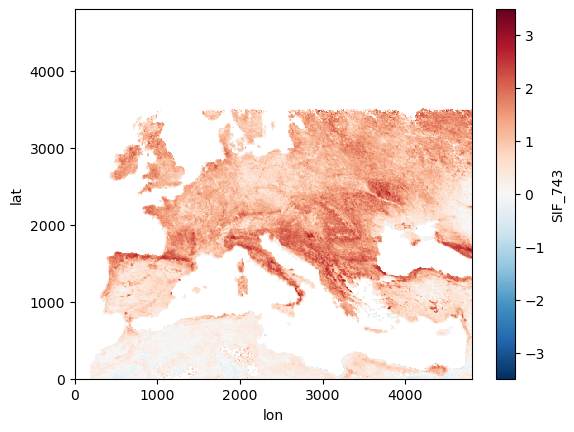

In [48]:
sif_cube_low_july['SIF_743'].plot()

In [49]:
sif_cube_low_july['SIF_743'].lon.dtype

dtype('float64')

In [50]:
# Rechunk after align important to increase efficiency
lst_cube_low = lst_cube_low.chunk({'lat': 80, 'lon': 80})
ndwi_cube_low = ndwi_cube_low.chunk({'lat': 80, 'lon': 80})
ogvi_cube_low = ogvi_cube_low.chunk({'lat': 80, 'lon': 80})

In [51]:
del lst_cube_low.lon.encoding['dtype']

In [52]:
del lst_cube_low.lat.encoding['dtype']

In [53]:
lst_cube_low.lon.encoding

{'chunks': (4800,),
 'preferred_chunks': {'lon': 4800},
 'compressors': (ZstdCodec(level=0, checksum=False),),
 'filters': (),
 'shards': None,
 'serializer': BytesCodec(endian=<Endian.little: 'little'>)}

In [54]:
sif_low_july_path

'/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/sif_cube_low_july.zarr'

In [55]:
# Save aggregated low-res data
print("Saving aggregated low-resolution data...")
os.makedirs(os.path.dirname(lst_low_july_path), exist_ok=True)
lst_cube_low.to_zarr(lst_low_july_path, mode='w')
ndwi_cube_low.to_zarr(ndwi_low_july_path, mode='w')
ogvi_cube_low.to_zarr(ogvi_low_july_path, mode='w')
sif_cube_low_july.to_zarr('/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/sif_cube_low_july_mod.zarr', mode = 'w')
print("Finished saving aggregated data.")

Saving aggregated low-resolution data...


/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Finished saving aggregated data.


/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Parameter optimization using low resolution data

In [25]:
# --- SIF Model Functions (Duveiller & Cescatti 2016) ---

def vegetation(vi, b1, b2):
    # Ensure inputs are numpy arrays for vectorized operations
    vi_np = np.asarray(vi)
    veg = b2 * np.power(vi_np, b1) 
    return veg

def water(et, b3, b4):
    
    et_np = np.asarray(et)
    
    wat = 1.0 / (1.0 + np.exp(b3 * (b4-et_np)))
    return wat

def temperature(lst, b5, b6):
    # Gaussian function, ensure b6 (std dev) is positive
    lst_np = np.asarray(lst)
    temp = np.exp(-0.5 * np.power((lst_np + b5) / b6, 2))
    
    return temp

'''
def sif_model(vi, et, lst, params):
    """Calculates SIF based on the model components."""
    b1, b2, b3, b4, b5, b6 = params
    sif_pred = (vegetation(vi, b1, b2) *
                water(et, b3, b4) *
                temperature(lst, b5, b6))
    return sif_pred


def cost_function(params, vi, et, lst, sif_observed):
    """Least squares cost function for optimization."""
    sif_pred = sif_model(vi, et, lst, params)
    # Calculate sum of squares, ignoring NaNs
    cost = np.nansum((sif_pred - sif_observed)**2)
    return cost

'''


def sif_model(vi, lst, params):
    """Calculates SIF based on the model components."""
    b1, b2, b5, b6 = params
    sif_pred = (vegetation(vi, b1, b2) *
                #water(et, b3, b4) *
                temperature(lst, b5, b6))
    return sif_pred

def cost_function(params, vi, lst, sif_observed):
    """Least squares cost function for optimization."""
    sif_pred = sif_model(vi, lst, params)
    # Calculate sum of squares, ignoring NaNs
    cost = np.nansum((sif_pred - sif_observed)**2)
    return cost


In [58]:
sif_cube_low_july = xr.open_zarr('/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/sif_cube_low_july_mod.zarr', chunks={})
lst_cube_low_july = xr.open_dataset(lst_low_july_path, chunks={})
ndwi_cube_low_july = xr.open_dataset(ndwi_low_july_path, chunks={})
ogvi_cube_low_july = xr.open_dataset(ogvi_low_july_path, chunks={})

In [59]:
# Name for the new dimension created by construct (holding flattened window elements)
window_dim_name = 'window_elements'

In [60]:

# Define window parameters
window_size_lat = 5
window_size_lon = 5

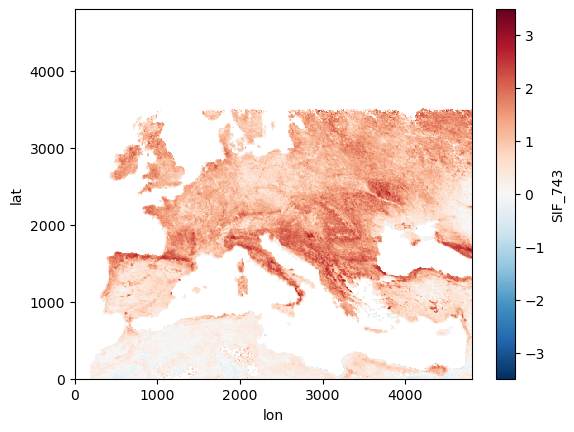

In [61]:
sif_cube_low_july['SIF_743'].plot()

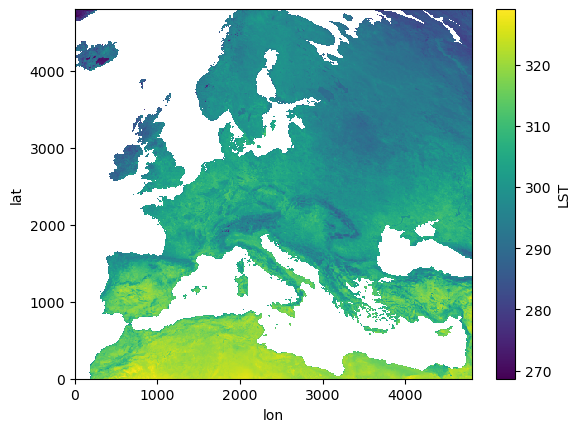

In [13]:
lst_cube_low_july['LST'].plot()

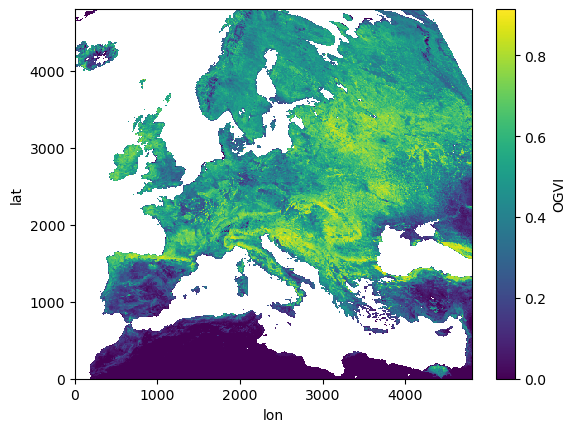

In [15]:
 ogvi_cube_low_july['OGVI'].plot()

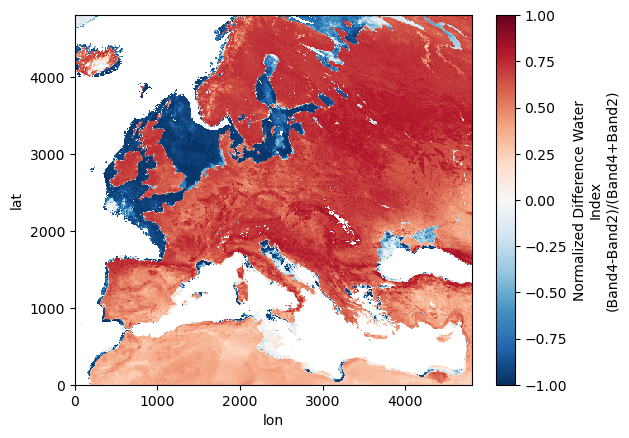

In [17]:
ndwi_cube_low_july['NDWI'].plot()

In [62]:
# --- Optimization Wrapper Function ---
'''
def optimize_params_window(sif_w, ogvi_w, ndwi_w, lst_w,
                           param_ini, param_bounds, min_obs):
    """
    Wrapper function to optimize SIF parameters for a single window.
    Designed to be used with apply_ufunc or iteration.
    Assumes input arrays (sif_w, etc.) are 2D numpy arrays (window data).
    """
    # Flatten the window arrays and filter out NaNs
    # Important: Filter consistently across all variables
    mask = ~np.isnan(sif_w) & ~np.isnan(ogvi_w) & ~np.isnan(ndwi_w) & ~np.isnan(lst_w)
    n_valid = np.sum(mask)

    if n_valid < min_obs:
        # Not enough valid observations in the window
        return np.full(len(param_ini), np.nan, dtype=np.float32)
    

    sif_obs_f = sif_w[mask]
    vi_f = ogvi_w[mask]
    et_f = ndwi_w[mask] # Using NDWI as proxy for water stress/ET effect
    lst_f = lst_w[mask]

    # Define bounds for L-BFGS-B
    bounds_scipy = list(zip(*param_bounds)) # [(min1, max1), (min2, max2), ...]

   
    result = minimize(cost_function,
                              x0=param_ini,
                              args=(vi_f, et_f, lst_f, sif_obs_f),
                              method='L-BFGS-B',
                              bounds=bounds_scipy,
                              options={'maxiter': 1000, 'ftol': 1e-7, 'gtol': 1e-5}) # Adjust options as needed

    optimized_params = np.array(np.clip(result.x, param_bounds[0], param_bounds[1]))
    #print(optimized_params.dtype)
    #print(optimized_params.size)
    #print(optimized_params.shape)
    return optimized_params
'''


def optimize_params_window(sif_w, ogvi_w, lst_w,
                           param_ini, param_bounds, min_obs):
    """
    Wrapper function to optimize SIF parameters for a single window.
    Designed to be used with apply_ufunc or iteration.
    Assumes input arrays (sif_w, etc.) are 2D numpy arrays (window data).
    """
    # Flatten the window arrays and filter out NaNs
    # Important: Filter consistently across all variables
    mask = ~np.isnan(sif_w) & ~np.isnan(ogvi_w) & ~np.isnan(lst_w)
    n_valid = np.sum(mask)

    if n_valid < min_obs:
        # Not enough valid observations in the window
        return np.full(len(param_ini), np.nan, dtype=np.float32)
    

    sif_obs_f = sif_w[mask]
    vi_f = ogvi_w[mask]
    #et_f = ndwi_w[mask] # Using NDWI as proxy for water stress/ET effect
    lst_f = lst_w[mask]

    # Define bounds for L-BFGS-B
    bounds_scipy = list(zip(*param_bounds)) # [(min1, max1), (min2, max2), ...]

   
    result = minimize(cost_function,
                              x0=param_ini,
                              args=(vi_f, lst_f, sif_obs_f),
                              method='L-BFGS-B',
                              bounds=bounds_scipy,
                              options={'maxiter': 1000, 'ftol': 1e-7, 'gtol': 1e-5}) # Adjust options as needed

    optimized_params = np.array(np.clip(result.x, param_bounds[0], param_bounds[1]))
    #print(optimized_params.dtype)
    #print(optimized_params.size)
    #print(optimized_params.shape)
    return optimized_params



In [69]:
'''
param_ini=np.array([1, 2, 50.0, 0, -295, 10])

param_min=np.array([0.5, 0.1, 0.0, -1, -310, 1])
param_max=np.array([1.5, 5, 500.0, 1, -290, 50])
param_bounds = np.array([param_min, param_max])


vi = np.array([0.3,0.2,0.4, 0.8, 0.2])
et = np.array([100.,200.,120., 40., 50.])
lst  = np.array([28.,30.,25., 21., 28.])

sif_ob = sif_model(vi, et, lst, np.array([1.35, 3, 120, -0.5, -291, 20]))
'''
'''
param_ini=np.array([1, 2, -295, 10])

param_min=np.array([0.5, 0.1, -310, 1])
param_max=np.array([1.5, 5, -290, 50])
param_bounds = np.array([param_min, param_max])


vi = np.array([0.3,0.2,0.4, 0.8, 0.2])
#et = np.array([100.,200.,120., 40., 50.])
lst  = np.array([28.,30.,25., 21., 28.])

sif_ob = sif_model(vi, lst, np.array([1.35, 3, -291, 20]))
'''

In [70]:
# optimize_params_window(sif_ob, vi, lst, param_ini, param_bounds, min_obs=2)

array([   1.,    2., -295.,   10.])

In [63]:
# --- Parameter Optimization ---
print("Starting parameter optimization using moving window...")

'''
# Define optimization parameters and bounds
param_ini = np.array([1.0, 2.0, 50.0, 0.0, -295.0, 10.0])
param_min = np.array([0.5, 0.1, 0.0, -1.0, -310.0, 1.0])
param_max = np.array([1.5, 5.0, 500.0, 1.0, -290.0, 50.0])
param_bounds = np.array([param_min, param_max])

min_obs_optim = 21 # Minimum valid observations in window
window_size_optim = 5 # Must match Julia 'window_edge'
'''

#'''
# Define optimization parameters and bounds
param_ini = np.array([1.0, 2.0, -295.0, 10.0])
param_min = np.array([0.5, 0.1, -310.0, 1.0])
param_max = np.array([1.5, 5.0, -290.0, 50.0])
param_bounds = np.array([param_min, param_max])

min_obs_optim = 21 # Minimum valid observations in window
window_size_optim = 5 # Must match Julia 'window_edge'
#'''

Starting parameter optimization using moving window...


In [65]:


# Prepare inputs for apply_ufunc
# We will apply the optimization function pixel-by-pixel on the low-res grid,
# but the function itself receives the data from the surrounding window.
'''
# Use xr.apply_ufunc for applying the windowed optimization
parameters_cube = xr.apply_ufunc(
    optimize_params_window, # Function to apply
    # Input arrays:
    sif_cube_low_july['SIF_743'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    ogvi_cube_low_july['OGVI'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    ndwi_cube_low_july['NDWI'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    lst_cube_low_july['LST'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    # Keyword arguments for the function:
    kwargs={'param_ini': param_ini, 'param_bounds': param_bounds, 'min_obs': min_obs_optim},
    # Define input core dimensions (the window dimensions):
    input_core_dims=[['lat_roll', 'lon_roll'], ['lat_roll', 'lon_roll'], ['lat_roll', 'lon_roll'], ['lat_roll', 'lon_roll']],
    # Define output core dimensions (the parameters dimension):
    output_core_dims=[['parameters']],
    dask_gufunc_kwargs={'output_sizes': {'parameters': 6}},
    # Specify the parameters dimension coordinates:
    dask='parallelized', # Enable Dask parallelization
    output_dtypes=[np.float64], # Specify output data type
    vectorize = True,
    # Add a new dimension 'parameters' to the output
    exclude_dims=set(('lat_roll', 'lon_roll')), # Exclude window dims from output
).rename('optimized_parameters')
'''

#'''
parameters_cube = xr.apply_ufunc(
    optimize_params_window, # Function to apply
    # Input arrays:
    sif_cube_low_july['SIF_743'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    ogvi_cube_low_july['OGVI'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    lst_cube_low_july['LST'].rolling(lat=window_size_lat, lon=window_size_lon, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    # Keyword arguments for the function:
    kwargs={'param_ini': param_ini, 'param_bounds': param_bounds, 'min_obs': min_obs_optim},
    # Define input core dimensions (the window dimensions):
    input_core_dims=[['lat_roll', 'lon_roll'], ['lat_roll', 'lon_roll'], ['lat_roll', 'lon_roll']],
    # Define output core dimensions (the parameters dimension):
    output_core_dims=[['parameters']],
    dask_gufunc_kwargs={'output_sizes': {'parameters': 4}},
    # Specify the parameters dimension coordinates:
    dask='parallelized', # Enable Dask parallelization
    output_dtypes=[np.float64], # Specify output data type
    vectorize = True,
    # Add a new dimension 'parameters' to the output
    exclude_dims=set(('lat_roll', 'lon_roll')), # Exclude window dims from output
).rename('optimized_parameters')

#'''

In [66]:
#output_cube = parameters_cube.compute()

In [67]:
#optimize_params_window(sif_cube_low_july['SIF_743'].values, ogvi_cube_low['OGVI'].values, ndwi_cube_low['NDWI'].values, lst_cube_low['LST'].values, param_ini=param_ini, param_bounds=param_bounds, min_obs=min_obs_optim)

In [68]:
parameters_cube

<xarray.DataArray 'optimized_parameters' (lat: 480, lon: 480, parameters: 4)> Size: 7MB
dask.array<transpose, shape=(480, 480, 4), dtype=float64, chunksize=(82, 82, 4), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 4.794e+03 4.784e+03 4.774e+03 ... 24.5 14.5 4.5
  * lon      (lon) float64 4kB 4.5 14.5 24.5 ... 4.774e+03 4.784e+03 4.794e+03
Dimensions without coordinates: parameters

In [70]:
# Assign coordinates to the new 'parameters' dimension
'''
parameters_cube['parameters'] = ["b1", "b2", "b3", "b4", "b5", "b6"]
parameters_cube = parameters_cube.chunk({'lat': 80, 'lon': 80, 'parameters': 6}) # Rechunk
'''

#'''
parameters_cube['parameters'] = ["b1", "b2", "b5", "b6"]
parameters_cube = parameters_cube.chunk({'lat': 80, 'lon': 80, 'parameters': 4}) # Rechunk
#'''

In [71]:
print("Optimization calculation graph defined. Computing and saving parameters...")
# Trigger computation and save
parameters_cube.to_zarr(params_low_path, mode='w', compute=True)
print(f"Saved low-resolution parameters to {params_low_path}")
print(f"Parameter cube shape: {parameters_cube.shape}")

Optimization calculation graph defined. Computing and saving parameters...


/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/core/array.py:4257: UserWarning: The dtype `<U2` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Net/Groups/BGI/scratc

Saved low-resolution parameters to /Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/parameters_cube_low_OGVI.zarr
Parameter cube shape: (480, 480, 4)


## Comparing python vs Julia parameters estimation

In [39]:
# Reload parameters if needed (e.g., after restarting kernel)
parameters_cube = xr.open_zarr(params_low_path, chunks={})
parameters_cube

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 7MB
Dimensions:               (parameters: 4, lon: 480, lat: 480)
Coordinates:
  * parameters            (parameters) object 32B 'b1' 'b2' 'b5' 'b6'
  * lon                   (lon) float64 4kB 4.5 14.5 ... 4.784e+03 4.794e+03
  * lat                   (lat) float64 4kB 4.794e+03 4.784e+03 ... 14.5 4.5
Data variables:
    optimized_parameters  (lat, lon, parameters) float64 7MB dask.array<chunksize=(80, 80, 4), meta=np.ndarray>

In [8]:
parameters_cube_julia = xr.open_dataset("/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/parameters_cube_low.zarr")

/tmp/ipykernel_3827836/899491499.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  parameters_cube_julia = xr.open_dataset("/Net/Groups/BGI/work_3/OEMC/oemc_sif/data/parameters_cube_low.zarr")
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'layer' has multiple fill values {np.float32(1e+32), np.float64(1e+32)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [9]:
parameters_cube_julia

<xarray.Dataset> Size: 6MB
Dimensions:           (X: 480, parameters_optim: 6, Y: 480)
Coordinates:
  * X                 (X) float64 4kB 1.0 2.0 3.0 4.0 ... 478.0 479.0 480.0
  * parameters_optim  (parameters_optim) object 48B 'b1' 'b2' 'b3' ... 'b5' 'b6'
  * Y                 (Y) float64 4kB 1.0 2.0 3.0 4.0 ... 478.0 479.0 480.0
Data variables:
    layer             (Y, X, parameters_optim) float32 6MB ...

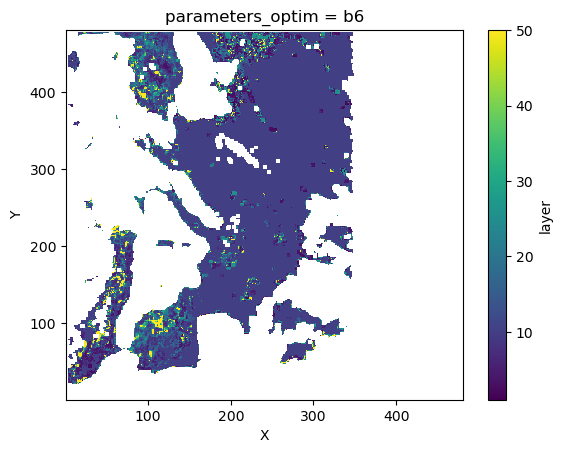

In [75]:
parameters_cube_julia['layer'].sel(parameters_optim = 'b6').plot()

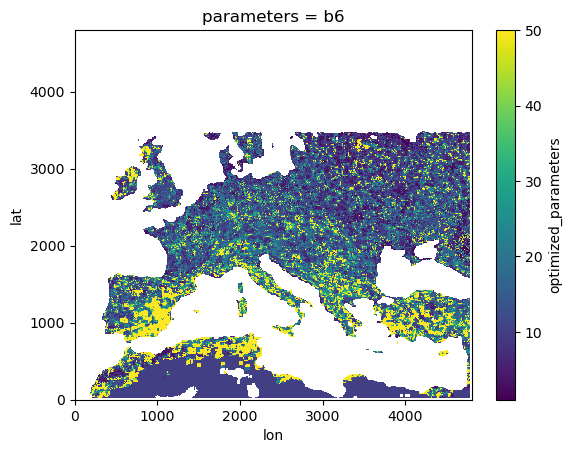

In [90]:
parameters_cube['optimized_parameters'].sel(parameters = 'b6').plot()

## Comparing predicted vs observed SIF at low resolution

In [81]:
'''
sif_predicted =  vegetation(ogvi_cube_low_july['OGVI'], parameters_cube['optimized_parameters'].sel(parameters = "b1"), parameters_cube['optimized_parameters'].sel(parameters = "b2")) * water(ndwi_cube_low_july['NDWI'], parameters_cube['optimized_parameters'].sel(parameters = "b3"), parameters_cube['optimized_parameters'].sel(parameters = "b4")) * temperature(lst_cube_low_july['LST'], parameters_cube['optimized_parameters'].sel(parameters = "b5"), parameters_cube['optimized_parameters'].sel(parameters = "b6"))
'''



#'''
sif_predicted =  vegetation(ogvi_cube_low_july['OGVI'], parameters_cube['optimized_parameters'].sel(parameters = "b1"), parameters_cube['optimized_parameters'].sel(parameters = "b2")) * temperature(lst_cube_low_july['LST'], parameters_cube['optimized_parameters'].sel(parameters = "b5"), parameters_cube['optimized_parameters'].sel(parameters = "b6"))
#'''

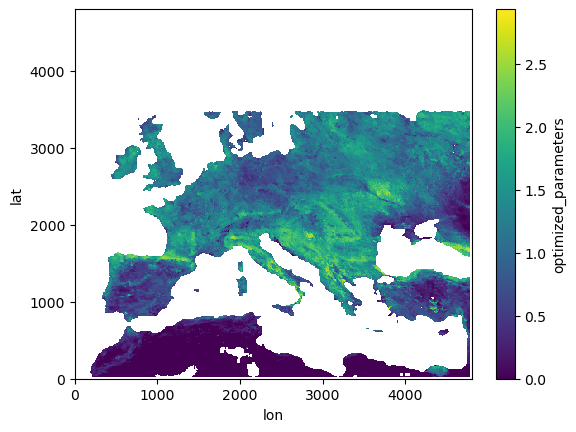

In [82]:
sif_predicted.plot()

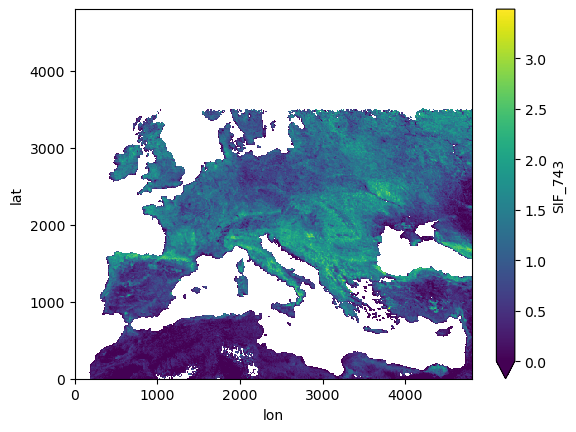

In [83]:
sif_cube_low_july['SIF_743'].plot(vmin = 0)

In [84]:
ob_vs_predicted = sif_cube_low_july['SIF_743'] - sif_predicted

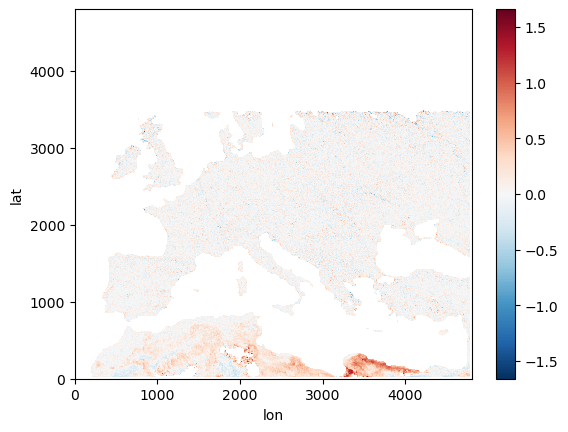

In [85]:
ob_vs_predicted.plot()

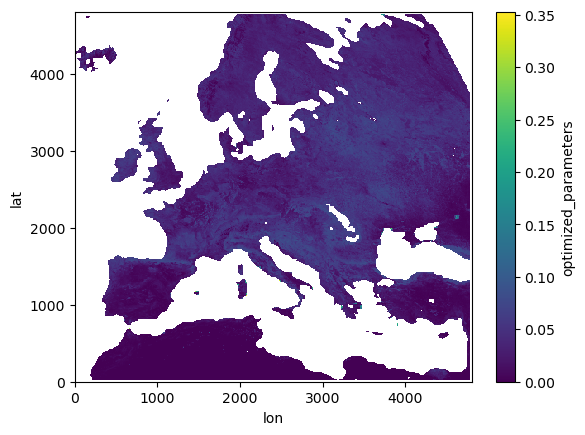

In [381]:
vegetation(ogvi_cube_low['OGVI'], parameters_cube['optimized_parameters'].sel(parameters = "b1"), parameters_cube['optimized_parameters'].sel(parameters = "b2")).plot()

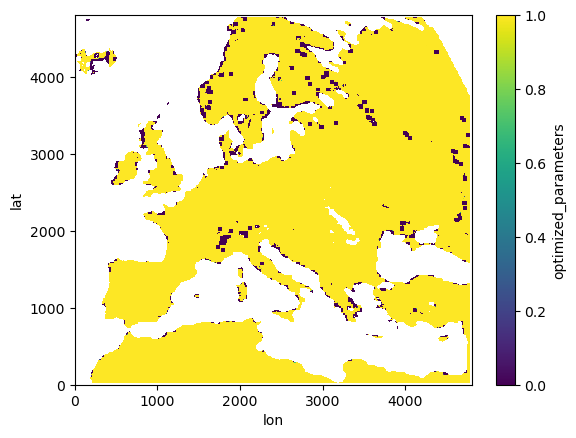

In [382]:
water(ndwi_cube_low['NDWI'], parameters_cube['optimized_parameters'].sel(parameters = "b3"), parameters_cube['optimized_parameters'].sel(parameters = "b4")).plot()

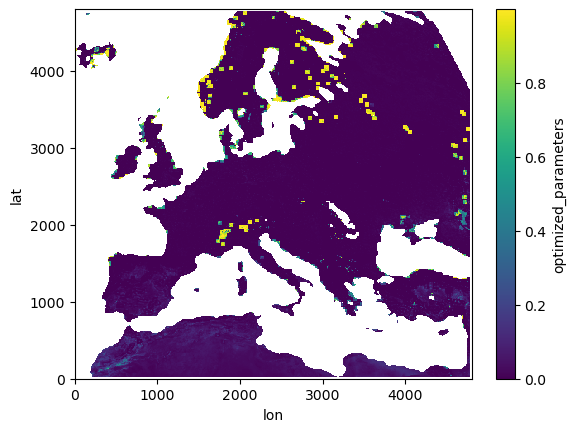

In [383]:
temperature(lst_cube_low['LST'], parameters_cube['optimized_parameters'].sel(parameters = "b5"), parameters_cube['optimized_parameters'].sel(parameters = "b6")).plot()

In [50]:
lst_cube_high_july

<xarray.DataArray 'LST' (lat: 4800, lon: 4800)> Size: 92MB
dask.array<rechunk-merge, shape=(4800, 4800), dtype=float32, chunksize=(80, 80), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) int64 38kB 4799 4798 4797 4796 4795 4794 4793 ... 5 4 3 2 1 0
  * lon      (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799

## Parameter interpolation

In [40]:
lst_cube_high_july = xr.open_dataset(lst_high_july_path)

In [41]:
np.any(np.isinf(parameters_cube['optimized_parameters'].values))

np.False_

In [42]:
np.isinf(parameters_cube['optimized_parameters'].values).sum()

np.int64(0)

In [64]:
# --- Parameter Disaggregation ---
print("Disaggregating parameters to high resolution...")

# Use interpolation (e.g., linear or nearest) to upscale
# Target grid is the high-resolution July grid (e.g., lst_cube_high_july)
# Ensure target grid coords match parameter cube spatial coords for interpolation
parameters_cube_high = parameters_cube.interp_like(
    lst_cube_high_july, # Use one of the high-res grids as template
    method="linear",    # Options: 'linear', 'nearest'
    #kwargs={"fill_value": "extrapolate"} # Optional: handle edges
    # Or fill_value=np.nan if extrapolation is not desired
   # kwargs = {'fill_value':np.nan},
).chunk({'lat': 400, 'lon': 400, 'parameters': -1}) # Rechunk for high-res

Disaggregating parameters to high resolution...


In [65]:
parameters_cube_high

<xarray.Dataset> Size: 737MB
Dimensions:               (parameters: 4, lat: 4800, lon: 4800)
Coordinates:
  * parameters            (parameters) object 32B 'b1' 'b2' 'b5' 'b6'
  * lon                   (lon) int64 38kB 0 1 2 3 4 ... 4796 4797 4798 4799
  * lat                   (lat) int64 38kB 4799 4798 4797 4796 4795 ... 3 2 1 0
Data variables:
    optimized_parameters  (lat, lon, parameters) float64 737MB dask.array<chunksize=(400, 400, 4), meta=np.ndarray>

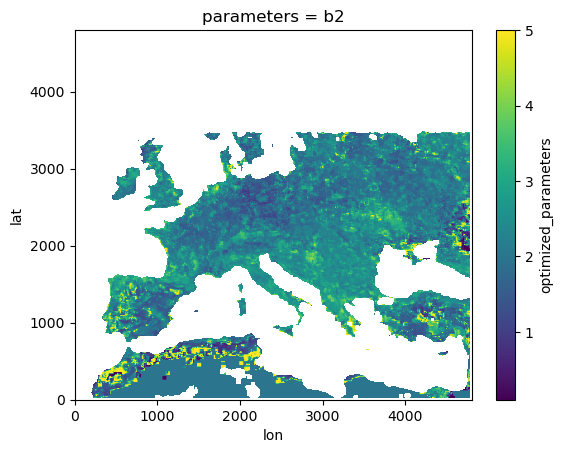

In [66]:
parameters_cube_high['optimized_parameters'].sel(parameters = 'b2').plot()

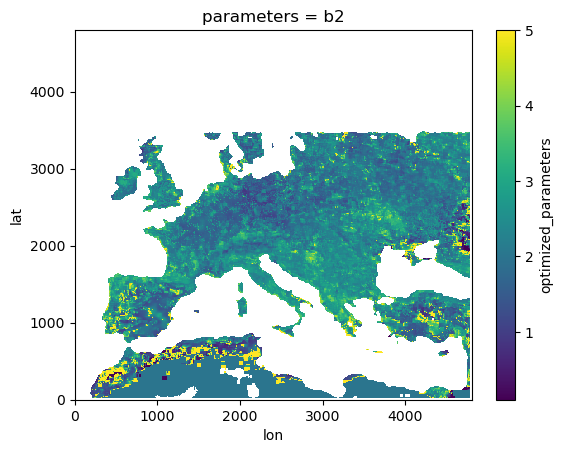

In [67]:
parameters_cube['optimized_parameters'].sel(parameters = 'b2').plot()

In [68]:
print("Disaggregation calculation graph defined. Computing and saving high-res parameters...")
parameters_cube_high.to_zarr(params_high_path, mode='w', compute=True)

Disaggregation calculation graph defined. Computing and saving high-res parameters...


/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/core/array.py:4257: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Net/Groups/

## SIF Downscaling

In [7]:
# loading data
ogvi_cube_high_july = xr.open_zarr(ogvi_high_july_path, chunks={})
ndwi_cube_high_july = xr.open_zarr(ndwi_high_july_path, chunks={})
lst_cube_high_july = xr.open_zarr(lst_high_july_path, chunks={})
parameters_cube_high = xr.open_zarr(params_high_path, chunks={})

/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


In [8]:
ogvi_cube_high_july.chunks

Frozen({'lat': (400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400), 'lon': (400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400)})

In [9]:
ndwi_cube_high_july.chunks

Frozen({'lat': (400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400), 'lon': (400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400)})

In [10]:
parameters_cube_high.chunks

Frozen({'lat': (400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400), 'lon': (400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400), 'parameters': (4,)})

In [11]:
np.all(parameters_cube_high['optimized_parameters'].lat == lst_cube_high_july.lat)

<xarray.DataArray 'lat' ()> Size: 1B
array(True)

In [12]:
np.all(parameters_cube_high['optimized_parameters'].lon == lst_cube_high_july.lon)

<xarray.DataArray 'lon' ()> Size: 1B
array(True)

In [13]:
np.all(parameters_cube_high['optimized_parameters'].lat == ogvi_cube_high_july.lat)

<xarray.DataArray 'lat' ()> Size: 1B
array(True)

In [14]:
np.all(parameters_cube_high['optimized_parameters'].lon == ogvi_cube_high_july.lon)

<xarray.DataArray 'lon' ()> Size: 1B
array(True)

In [15]:
# --- SIF Downscaling ---
print("Starting SIF downscaling using high-resolution data and parameters...")



# Define the wrapper function for downscaling within a window
def sif_downscaling_window(ogvi_hw, lst_hw, params_hw):
    """
    Calculates downscaled SIF for a central pixel based on window means.
    Inputs are 3D numpy arrays (window_x, window_y, [parameters]).
    """
   

    # Calculate mean parameters within the window (ignore NaNs)
    # Need to handle case where all params in window are NaN
    mean_params = np.nanmean(params_hw, axis=(0,1))

    if np.all(np.isnan(mean_params)):
        return np.array([np.nan]) # Cannot calculate if no valid parameters in window)

    # Calculate mean predictors within the window (ignore NaNs)
    mean_ogvi = np.nanmean(ogvi_hw)
    #mean_ndwi = np.nanmean(ndwi_hw)
    mean_lst = np.nanmean(lst_hw)

    # Check if any mean predictor is NaN (means all values in window were NaN)
    if np.isnan(mean_ogvi) or np.isnan(mean_lst):
        return np.array([np.nan])

    # Apply SIF model using mean values
    sif_ds = sif_model(mean_ogvi, mean_lst, mean_params)
    return np.array([sif_ds])
    

Starting SIF downscaling using high-resolution data and parameters...


In [16]:
window_size_downscale = 3


In [17]:
ogvi_cube_high_july['OGVI'].rolling(lat=window_size_downscale, lon=window_size_downscale, center=True).construct(lat = 'lat_roll', lon = 'lon_roll')

<xarray.DataArray 'OGVI' (lat: 4800, lon: 4800, lat_roll: 3, lon_roll: 3)> Size: 829MB
dask.array<sliding_window_view, shape=(4800, 4800, 3, 3), dtype=float32, chunksize=(401, 401, 3, 3), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) int64 38kB 4799 4798 4797 4796 4795 4794 4793 ... 5 4 3 2 1 0
  * lon      (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799
Dimensions without coordinates: lat_roll, lon_roll

In [18]:
lst_cube_high_july['LST'].rolling(lat=window_size_downscale, lon=window_size_downscale, center=True).construct(lat = 'lat_roll', lon = 'lon_roll')

<xarray.DataArray 'LST' (lat: 4800, lon: 4800, lat_roll: 3, lon_roll: 3)> Size: 829MB
dask.array<sliding_window_view, shape=(4800, 4800, 3, 3), dtype=float32, chunksize=(401, 401, 3, 3), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799
  * lat      (lat) int64 38kB 4799 4798 4797 4796 4795 4794 4793 ... 5 4 3 2 1 0
Dimensions without coordinates: lat_roll, lon_roll

In [19]:
 parameters_cube_high['optimized_parameters'].rolling(lat=window_size_downscale, lon=window_size_downscale, center=True).construct(lat = 'lat_roll', lon = 'lon_roll').chunk({'parameters':-1})

<xarray.DataArray 'optimized_parameters' (lat: 4800, lon: 4800, parameters: 4,
                                          lat_roll: 3, lon_roll: 3)> Size: 7GB
dask.array<rechunk-merge, shape=(4800, 4800, 4, 3, 3), dtype=float64, chunksize=(401, 401, 4, 3, 3), chunktype=numpy.ndarray>
Coordinates:
  * lon         (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799
  * lat         (lat) int64 38kB 4799 4798 4797 4796 4795 4794 ... 5 4 3 2 1 0
  * parameters  (parameters) object 32B 'b1' 'b2' 'b5' 'b6'
Dimensions without coordinates: lat_roll, lon_roll

In [20]:
print("Applying downscaling function...")
sif_cube_high = xr.apply_ufunc(
    sif_downscaling_window,
    # Input arrays with rolling windows constructed
    ogvi_cube_high_july['OGVI'].rolling(lat=window_size_downscale, lon=window_size_downscale, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    #ndwi_aligned.rolling({x_dim: window_size_downscale, y_dim: window_size_downscale}, center=True).construct(x_dim+'_w', y_dim+'_w'),
    lst_cube_high_july['LST'].rolling(lat=window_size_downscale, lon=window_size_downscale, center=True).construct(lat = 'lat_roll', lon = 'lon_roll'),
    parameters_cube_high['optimized_parameters'].rolling(lat=window_size_downscale, lon=window_size_downscale, center=True).construct(lat = 'lat_roll', lon = 'lon_roll').chunk({'parameters':-1}),
    # Input core dimensions now include the window dims and the parameter dim for the last input
    input_core_dims=[['lat_roll', 'lon_roll'],
                     ['lat_roll', 'lon_roll'],
                     ['lat_roll', 'lon_roll', 'parameters']],
    # Output is scalar for each pixel (no core dims)
    output_core_dims=[['SIF_downscaled']],
    dask_gufunc_kwargs={'output_sizes': {'SIF_downscaled': 1}},
    dask='parallelized',
    output_dtypes=[np.float64],
    vectorize = True,
    exclude_dims=set(('lat_roll', 'lon_roll')), # Exclude window dims from output
).rename('SIF_downscaled')


Applying downscaling function...


In [31]:
sif_cube_high = sif_cube_high.to_dataset(name = 'SIF')

In [32]:
#sif_cube_high.compute()

In [33]:
# Assign attributes maybe
#sif_cube_high.attrs = sif_cube_low_july.attrs # Copy attrs from original SIF
sif_cube_high.attrs['description'] = f'Downscaled SIF using Duveiller&Cescatti method, {window_size_downscale}x{window_size_downscale} window smoothing'

In [34]:
sif_cube_high = sif_cube_high.chunk({'lat':800, 'lon':800})

In [35]:
print("Downscaling calculation graph defined. Computing and saving high-res SIF...")
sif_cube_high.to_zarr(sif_high_path, mode='w', compute=True)
print(f"Saved high-resolution downscaled SIF to {sif_high_path}")

Downscaling calculation graph defined. Computing and saving high-res SIF...


/Net/Groups/BGI/scratch/dpabon/miniforge3/envs/oemc_sif/lib/python3.13/site-packages/zarr/api/asynchronous.py:205: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved high-resolution downscaled SIF to /Net/Groups/BGI/work_3/OEMC/oemc_sif/data/python_output/sif_downscaled_high_OGVI.zarr


AttributeError: 'Dataset' object has no attribute 'shape'

## Checking results

In [11]:
sif_cube_high_july = xr.open_dataset(sif_high_path, chunks={})
sif_cube_high_july

<xarray.Dataset> Size: 184MB
Dimensions:  (lon: 4800, lat: 4800, SIF_downscaled: 1)
Coordinates:
  * lon      (lon) int64 38kB 0 1 2 3 4 5 6 ... 4794 4795 4796 4797 4798 4799
  * lat      (lat) int64 38kB 4799 4798 4797 4796 4795 4794 4793 ... 5 4 3 2 1 0
Dimensions without coordinates: SIF_downscaled
Data variables:
    SIF      (lat, lon, SIF_downscaled) float64 184MB dask.array<chunksize=(800, 800, 1), meta=np.ndarray>
Attributes:
    description:  Downscaled SIF using Duveiller&Cescatti method, 3x3 window ...

In [12]:
sif_cube_low_july = xr.open_dataset(sif_low_july_path, chunks={})
sif_cube_low_july

<xarray.Dataset> Size: 929kB
Dimensions:  (lon: 480, lat: 480)
Coordinates:
  * lon      (lon) int64 4kB 0 1 2 3 4 5 6 7 ... 472 473 474 475 476 477 478 479
  * lat      (lat) int64 4kB 479 478 477 476 475 474 473 472 ... 7 6 5 4 3 2 1 0
Data variables:
    SIF_743  (lat, lon) float32 922kB dask.array<chunksize=(80, 80), meta=np.ndarray>

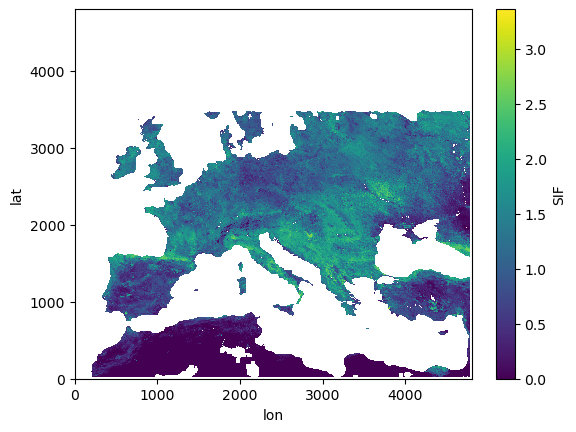

In [13]:
sif_cube_high_july['SIF'].plot()

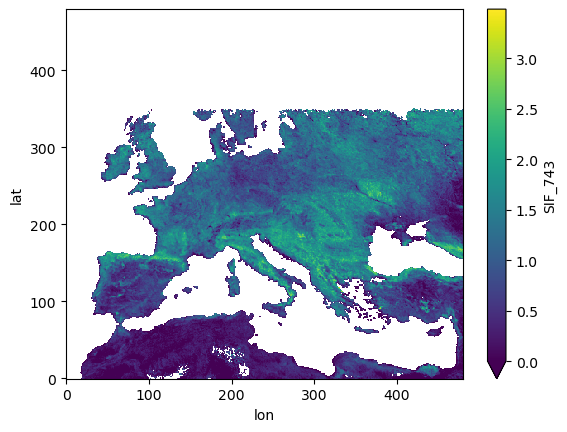

In [15]:
sif_cube_low_july['SIF_743'].plot(vmin = 0)